In [1]:
# Installation des packages et récupération des données

import sys

!mc mirror s3/hlegarzic/stat_app/ /home/onyxia/data/MINI-DDSM/

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install matplotlib tqdm seaborn scikit-learn

]11;?\

...57212e.png: 56.60 GiB / 56.60 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 202.57 MiB/s 4m46s
== WARN: `minio.lab.sspcloud.fr` certificate will expire in 2026-02-26 12:48:48 +0000 UTC. Renew soon to avoid outage.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.4 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 71.8 MB/s  0:00:006m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [seaborn]0/11 [seaborn]ib]n]


In [2]:
# Imports
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split   
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter

# Vérification GPU
print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU, utilisation du CPU")

GPU disponible : True
GPU détecté : NVIDIA A2


In [3]:
# Restructuration des données
import os
import shutil

def restructure_normale_data():
    source = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-8/Normal"
    destination = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/normal"
    os.makedirs(destination, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
            
        chemin_MLO_right = os.path.join(source_filename, "A_" + filename + "_1.RIGHT_MLO.jpg")
        chemin_MLO_left = os.path.join(source_filename, "A_" + filename + "_1.LEFT_MLO.jpg")
        
        if os.path.exists(chemin_MLO_right):
            shutil.copy2(chemin_MLO_right, destination)
        if os.path.exists(chemin_MLO_left):
            shutil.copy2(chemin_MLO_left, destination)
    
    print("✓ Restructuration Normal terminée")


def restructuration_cancer():
    source = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-8/Cancer"
    destination1 = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/cancer_benign"
    destination2 = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/normal"
    os.makedirs(destination1, exist_ok=True)
    os.makedirs(destination2, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
        
        # Identification de la lettre correcte
        ok = False
        i = 0
        l = ["A_", "B_", "C_", "D_"]
        
        while not ok and i < 4:
            chemin_MLO_right = os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i += 1
        
        if i == 4:
            print(f"Erreur1 avec le fichier {filename}")
            continue
        
        # Identification cancer gauche ou droit
        orientation = None
        if os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.OVERLAY")):
            orientation = "RIGHT"
        elif os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.OVERLAY")):
            orientation = "LEFT"
        else:
            print(f"Cancer uniquement visible sur le point de vue CC : {filename}")
        
        # Copie des images
        if orientation == "RIGHT":
            shutil.copy2(chemin_MLO_right, destination1)
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination2)
        elif orientation == "LEFT":
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination1)
            if os.path.exists(chemin_MLO_right):
                shutil.copy2(chemin_MLO_right, destination2)
    
    print("Restructuration Cancer terminée")


def restructuration_benign():
    source = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-8/Benign"
    destination1 = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/cancer_benign"
    destination2 = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/normal"
    os.makedirs(destination1, exist_ok=True)
    os.makedirs(destination2, exist_ok=True)
    
    for filename in os.listdir(source):
        source_filename = os.path.join(source, filename)
        if not os.path.isdir(source_filename):
            continue
        
        # Identification de la lettre correcte
        ok = False
        i = 0
        l = ["A_", "B_", "C_", "D_"]
        
        while not ok and i < 4:
            chemin_MLO_right = os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.jpg")
            if os.path.exists(chemin_MLO_right):
                ok = True
            else:
                i += 1
        
        if i == 4:
            print(f"Erreur1 avec le fichier {filename}")
            continue
        
        # Identification benign gauche ou droit
        orientation = None
        if os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.RIGHT_MLO.OVERLAY")):
            orientation = "RIGHT"
        elif os.path.exists(os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.OVERLAY")):
            orientation = "LEFT"
        else:
            print(f"Benign uniquement visible sur le point de vue CC : {filename}")
        
        # Copie des images
        if orientation == "RIGHT":
            shutil.copy2(chemin_MLO_right, destination1)
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination2)
        elif orientation == "LEFT":
            chemin_MLO_left = os.path.join(source_filename, l[i] + filename + "_1.LEFT_MLO.jpg")
            if os.path.exists(chemin_MLO_left):
                shutil.copy2(chemin_MLO_left, destination1)
            if os.path.exists(chemin_MLO_right):
                shutil.copy2(chemin_MLO_right, destination2)
    
    print("Restructuration Benign terminée")


# Exécution de la restructuration
print("Début de la restructuration des données...")
print("=" * 60)

restructure_normale_data()
restructuration_cancer()
restructuration_benign()

print("=" * 60)
print("Restructuration complète terminée !")

# Vérification des résultats
print("\n Vérification des données restructurées :")
base_path = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82"
for classe in ["normal", "cancer_benign"]:
    chemin = os.path.join(base_path, classe)
    if os.path.exists(chemin):
        nb_images = len([f for f in os.listdir(chemin) if f.endswith('.jpg')])
        print(f"  - {classe}: {nb_images} images")
    else:
        print(f"  - {classe}: dossier non trouvé")

Début de la restructuration des données...
✓ Restructuration Normal terminée
Cancer uniquement visible sur le point de vue CC : 1557
Cancer uniquement visible sur le point de vue CC : 1903
Cancer uniquement visible sur le point de vue CC : 0091
Cancer uniquement visible sur le point de vue CC : 0052
Cancer uniquement visible sur le point de vue CC : 3054
Cancer uniquement visible sur le point de vue CC : 3033
Cancer uniquement visible sur le point de vue CC : 1662
Cancer uniquement visible sur le point de vue CC : 3500
Cancer uniquement visible sur le point de vue CC : 0222
Cancer uniquement visible sur le point de vue CC : 4140
Restructuration Cancer terminée
Benign uniquement visible sur le point de vue CC : 1714
Benign uniquement visible sur le point de vue CC : 3155
Benign uniquement visible sur le point de vue CC : 0367
Benign uniquement visible sur le point de vue CC : 1869
Benign uniquement visible sur le point de vue CC : 1786
Benign uniquement visible sur le point de vue CC : 

In [4]:
# Génération des données équilibrées
# Transformation des données
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_set = ImageFolder(root="/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82", transform=transform)
label = np.array(data_set.targets)

print(f"Nombre total d'images : {len(label)}")
print(f"Classes détectées : {data_set.classes}")
print(f"Distribution des classes : {Counter(label)}")

# Split stratifié des données
numero_random = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(label)), label):
    train_val_indices = train_val_index
    test_indices = test_index

train_val_labels = label[train_val_indices]
new_val_size = val_size / (train_size + val_size)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in sss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices = train_val_indices[train_index]
    val_indices = train_val_indices[val_index]

print(f"Train set: {len(train_indices)}")
print(f"Validation set: {len(val_indices)}")
print(f"Test set: {len(test_indices)}")

# Weighted Sampler pour équilibrer les classes
train_labels = label[train_indices]
class_counts = Counter(train_labels)
print(f"Distribution dans train : {class_counts}")

num_labels = len(train_labels)
weight_for_class = {cl: num_labels / count for cl, count in class_counts.items()}
sample_weights = [weight_for_class[l] for l in train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

print(f"Poids par classe : {weight_for_class}")

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor, 
    num_samples=len(sample_weights_tensor), 
    replacement=True
)

train_set = Subset(data_set, train_indices)
val_set = Subset(data_set, val_indices)
test_set = Subset(data_set, test_indices)

bs = 32
train_loader = DataLoader(train_set, batch_size=bs, sampler=sampler)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False)

Nombre total d'images : 3666
Classes détectées : ['cancer_benign', 'normal']
Distribution des classes : Counter({np.int64(1): 2333, np.int64(0): 1333})
Train set: 2566
Validation set: 550
Test set: 550
Distribution dans train : Counter({np.int64(1): 1633, np.int64(0): 933})
Poids par classe : {np.int64(1): 1.571341090018371, np.int64(0): 2.7502679528403}


In [5]:
# Entraînement du modèle
# Création du modèle et configuration GPU
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_class = len(data_set.classes)
model.fc = torch.nn.Linear(model.fc.in_features, num_class)

# Configuration GPU
device = torch.device("cuda:0")
print(f"Device utilisé : {device}")
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.1, patience=3, threshold=0.0001
)

print(f"Modèle configuré avec {num_class} classes")

# Fonctions d'entraînement et validation
def train_model(model, train_loader, val_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in tqdm(train_loader, desc="Entraînement"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss


def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    corrects = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = corrects.double() / len(val_loader.dataset)
    
    return epoch_loss, epoch_acc

# Boucle d'entraînement avec early stopping
num_epochs = 10  
best_acc = 0.0
patience_limite = 5
patience_compteur = 0

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Époque {epoch+1}/{num_epochs}")
    print(f"{'='*50}")
    
    # Entraînement
    train_loss = train_model(model, train_loader, val_loader, criterion, optimizer)
    print(f"Loss d'entraînement: {train_loss:.4f}")
    
    # Validation
    val_loss, val_acc = validate_model(model, val_loader, criterion, device)
    print(f"Loss de validation: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    
    # Scheduler
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate: {current_lr}")
    
    # Sauvegarde du meilleur modèle
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/home/onyxia/best_resnet18_model.pth")
        # Sauvegarder sur S3
        !mc cp /home/onyxia/best_resnet18_model.pth s3/hlegarzic/stat_app/
        print(f"Nouveau meilleur modèle sauvegardé (acc: {best_acc:.4f})")
        patience_compteur = 0
    else:
        patience_compteur += 1
        print(f"Patience: {patience_compteur}/{patience_limite}")
        
        if patience_compteur >= patience_limite:
            print("\n Early stopping déclenché")
            break

print(f"\n{'='*50}")
print(f"Entraînement terminé. Meilleure accuracy: {best_acc:.4f}")
print(f"{'='*50}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/onyxia/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


Device utilisé : cuda:0
Modèle configuré avec 2 classes

Époque 1/10


Entraînement: 100%|██████████| 81/81 [03:43<00:00,  2.76s/it]


Loss d'entraînement: 0.5636


...

Entraînement: 100%|██████████| 81/81 [03:36<00:00,  2.67s/it]


Loss d'entraînement: 0.0260


Validation: 100%|██████████| 18/18 [00:32<00:00,  1.82s/it]

Loss de validation: 0.8559 | Accuracy: 0.6818
Learning rate: 0.0001
]11;?\

..._model.pth: 42.72 MiB / 42.72 MiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 133.42 MiB/s 0s
== WARN: `minio.lab.sspcloud.fr` certificate will expire in 2026-02-26 12:48:48 +0000 UTC. Renew soon to avoid outage.

Nouveau meilleur modèle sauvegardé (acc: 0.6818)

Entraînement terminé. Meilleure accuracy: 0.6818


100%|██████████| 18/18 [00:33<00:00,  1.87s/it]

Test_Accuracy : 68.5455%


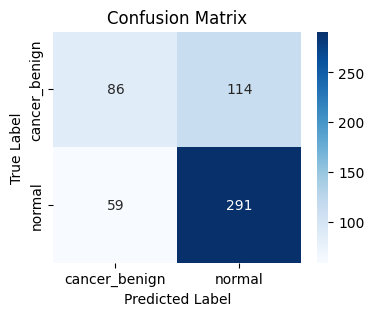

Rapport de classification : 
               precision    recall  f1-score   support

cancer_benign       0.59      0.43      0.50       200
       normal       0.72      0.83      0.77       350

     accuracy                           0.69       550
    macro avg       0.66      0.63      0.63       550
 weighted avg       0.67      0.69      0.67       550



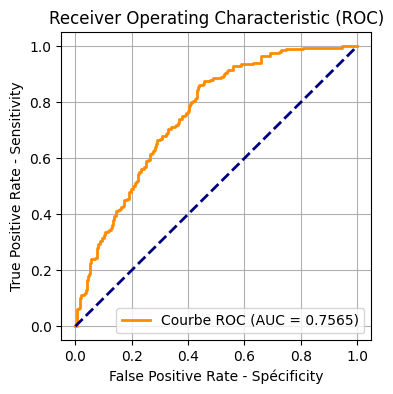

In [9]:
# Évaluation sur le test set
import torch.nn.functional as F
model.load_state_dict(torch.load("/home/onyxia/best_resnet18_model.pth"))

model.eval()
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities[:, 0].cpu().numpy())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification : ")
print(report)

# Courbe ROC et AUC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()